In [15]:
import bacco
import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.spatial import KDTree

In [17]:
import sys
sys.path.append("/cosmos_storage/home/fgmaion/MTNG-resims/src")
import utils
import merger_tree_tools as mgt

In [18]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Load the Zoom

In [19]:
base = "/cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/"

sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME

zoom_z0 = bacco.Simulation(basedir=base, halo_file="groups_{:03d}/fof_subhalo_tab_{:03d}".format(264,264), sim_format='TNG500', fixedPk=True, use_orphans=False,\
                        tau=tau, ns=ns, sigma8=sigma8, use_ids=False, tree_file="groups_{:03d}/subhalo_prog_{:03d}".format(264,264), numpart=4320)

2026-05-18 23:05:54,925 bacco.sims : Initialising simulation Default
2026-05-18 23:05:54,926 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/groups_264/fof_subhalo_tab_264
2026-05-18 23:05:54,948 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/groups_264/fof_subhalo_tab_264


2026-05-18 23:05:54,990 bacco.sims : ...done in 0.065 s
Exception ignored in: <function Simulation.__del__ at 0x2b91379b74c0>
Traceback (most recent call last):
  File "/lscratch/fgmaion/baccogit/bacco/simulation.py", line 587, in __del__
    self.cleanup()
  File "/lscratch/fgmaion/baccogit/bacco/simulation.py", line 11034, in cleanup
    self.Cosmology.cleanup()
AttributeError: 'Simulation' object has no attribute 'Cosmology'
Exception ignored in: <function Simulation.__del__ at 0x2b91379b74c0>
Traceback (most recent call last):
  File "/lscratch/fgmaion/baccogit/bacco/simulation.py", line 587, in __del__
    self.cleanup()
  File "/lscratch/fgmaion/baccogit/bacco/simulation.py", line 11034, in cleanup
    self.Cosmology.cleanup()
AttributeError: 'Simulation' object has no attribute 'Cosmology'
Exception ignored in: <function Simulation.__del__ at 0x2b91379b74c0>
Traceback (most recent call last):
  File "/lscratch/fgmaion/baccogit/bacco/simulation.py", line 587, in __del__
    self.

First cross-match z=0 to other z

In [6]:
with open("/lscratch/fgmaion/MTNG-resims/halo_selection/hydro_halo_sel_1pmbin.txt") as f:
    final_sel = []

    for line in f.readlines():
        final_sel.append(int(line.split()[0]))
        
final_sel = np.array(final_sel)

snap_0 = 264

tree = mgt.tree(snap_0=snap_0) # class object containing methods related to the merger-trees
tree.get_tree_props(final_sel)

2024-11-06 12:36:46,600 bacco.sims : Initialising simulation Default
2024-11-06 12:36:46,601 bacco.sims : try /cosmos_storage/simulations/MTNG/groups_264/fof_subhalo_tab_264
2024-11-06 12:36:46,602 bacco.sims : Loading /cosmos_storage/simulations/MTNG/groups_264/fof_subhalo_tab_264
2024-11-06 12:36:46,608 bacco.sims : ...done in 0.00882 s
2024-11-06 12:36:46,614 bacco.sims : Reading 98233510 items for halo_firstsub


Tree incomplete417
Tree incomplete449


In [7]:
idx = tree.walk_tree()

sel_214 = np.zeros(len(final_sel), dtype=int)
sel_200 = np.zeros(len(final_sel), dtype=int)
sel_100 = np.zeros(len(final_sel), dtype=int)

for i in range(len(final_sel)):
    sel_214[i] = tree.group_nr[i][idx[i,snap_0-214]]
    sel_200[i] = tree.group_nr[i][idx[i,snap_0-200]]
    sel_100[i] = tree.group_nr[i][idx[i,snap_0-100]]

### Cross-Match Selected Halos

In general there is a large-scale shift between the positions of resimulated halos and the original ones. This is simply due to the poor resolution of large-scale forces

For this we can use the work done by Kurt Walsen, of finding the large-scale displacements between the zoomed regions and the original MTNG.

In the files <code>/lscratch/kwalsen/xmatch/*/selection_xmatch_deltas.csv</code> we have:

- Halo-index for z=0 MTNG group-files
- Halo-index for z=0 zoom group-files
- dx, dy, dz -- Large-Scale displacements used to find a good cross-match between full resimulated region

**I won't use this for now because I want this cross-matching at many different redshifts**


In [56]:
# Even if I'm not using it now, here's how to read Kurt's data
fid_xm = utils.read_central_xmatch("fiducial")

failed for line: ['34', '67746', '-', '-0.029510498046875', '0.040715535481770836', '0.7389119466145834']
failed for line: ['277', '1516796', '-', '-', '-']
failed for line: ['427', '3248135', '-', '-', '-']


### Now cross-match those at same redshift

In [67]:
xm_214 = utils.cross_match(zoom_214, mtng_214, sel_214)

In [16]:
ihalo = 400

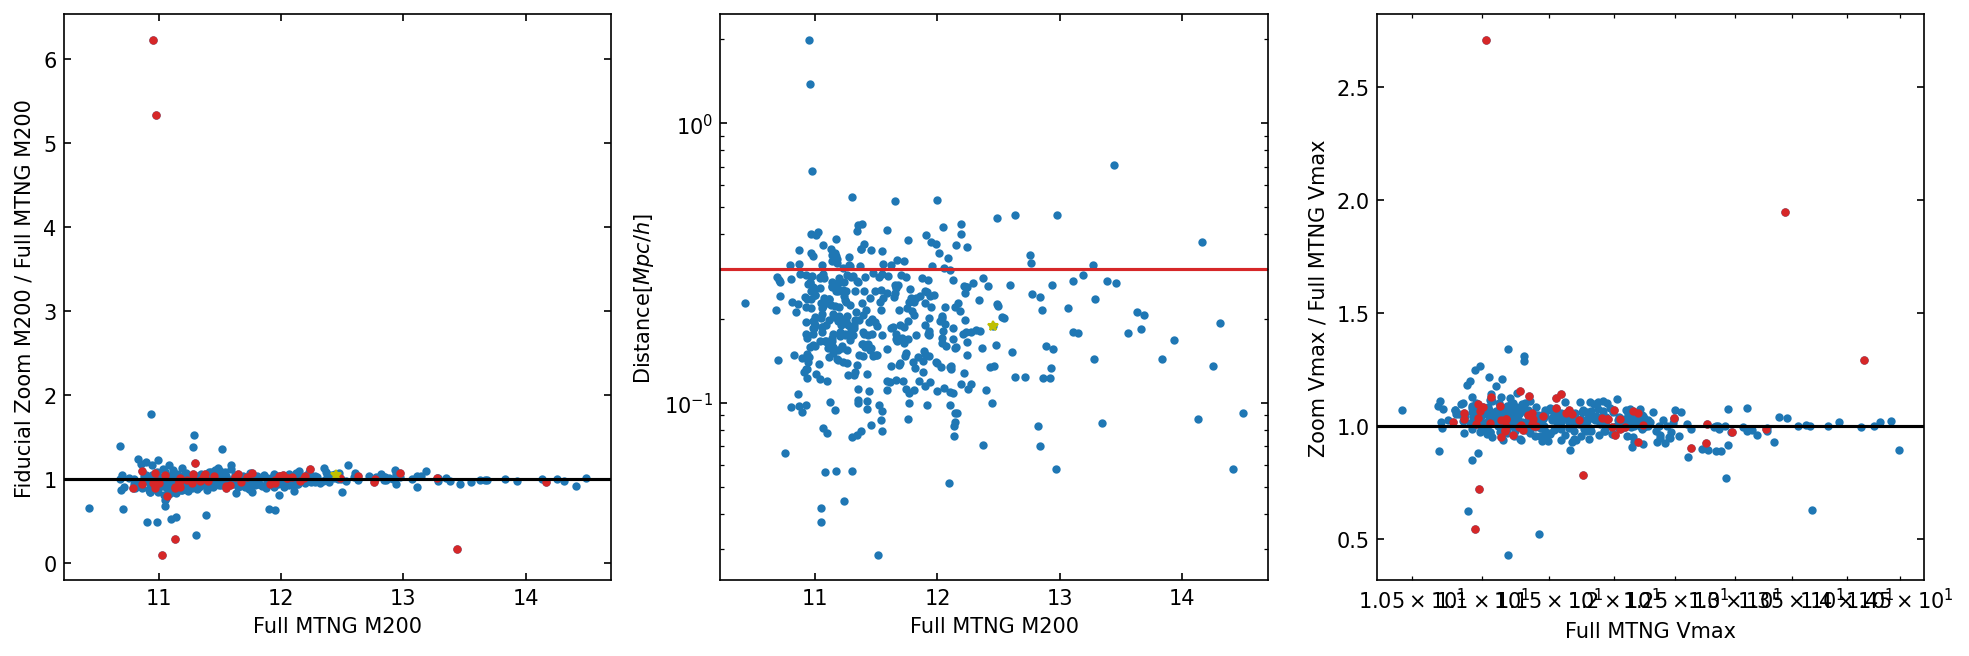

In [69]:
fig, ax = plt.subplots(1, 3, dpi=150, figsize=(16,5))

w = np.where(xm_214['dm']>0.3)

Xarr = np.log10(1e10*mtng_214.fof['halo_m200b'][sel_214])
Yarr = (zoom_214.fof['halo_m200b'][psel[xm_214['xm']]] / mtng_214.fof['halo_m200b'][sel_214])

Xarr_out = np.log10(1e10*mtng_214.fof['halo_m200b'][sel_214][w])
Yarr_out = (zoom_214.fof['halo_m200b'][psel[xm_214['xm']]][w] / mtng_214.fof['halo_m200b'][sel_214][w])

ax[0].plot(Xarr, Yarr, marker='o', color='C0', ms=3, ls='')
ax[0].plot(Xarr_out, Yarr_out, marker='o', color='C3', ms=3, ls='')

ax[0].plot(Xarr[ihalo], Yarr[ihalo], marker='*', color='y', ms=5, ls='')

ax[0].axhline(1, color='k')

ax[0].set_xlabel('Full MTNG M200')
ax[0].set_ylabel('Fiducial Zoom M200 / Full MTNG M200')

#

ax[1].set_xlabel('Full MTNG M200')
ax[1].set_ylabel('Distance$[Mpc/h]$')

ax[1].plot(np.log10(1e10*mtng_214.fof['halo_m200b'][sel_214]), xm_214['dm'], marker='o', color='C0', ms=3, ls='')
ax[1].plot(np.log10(1e10*mtng_214.fof['halo_m200b'][sel_214][ihalo]), xm_214['dm'][ihalo], marker='*', color='y', ms=5, ls='')

#ax[1].set_xlim(8,14)
ax[1].axhline(0.3, color='C3')

ax[1].set_yscale('log')

#

ax[2].set_xscale('log')

ax[2].set_xlabel('Full MTNG Vmax')
ax[2].set_ylabel('Zoom Vmax / Full MTNG Vmax')

ax[2].plot(np.log10(1e10*mtng_214.fof['halo_m200b'][sel_214]), mtng_214.sub['vmax'][mtng_214.fof['halo_firstsub'][sel_214]] / zoom_214.sub['vmax'][zoom_214.fof['halo_firstsub'][psel[xm_214['xm']]]], marker='o', color='C0', ms=3, ls='')
ax[2].plot(np.log10(1e10*mtng_214.fof['halo_m200b'][sel_214][w]), mtng_214.sub['vmax'][mtng_214.fof['halo_firstsub'][sel_214][w]] / zoom_214.sub['vmax'][zoom_214.fof['halo_firstsub'][psel[xm_214['xm']][w]]], marker='o', color='C3', ms=3, ls='')

ax[2].axhline(1, color='k')

### Let's work in a specific region

We will focus on one of the zoom halos

In [ ]:
Pzoom = zoom.fof['halo_pos'][psel][xmatch]
Pmtng = mtng.fof['halo_pos'][sel_z]

In [ ]:
center = Pmtng[ihalo]

In [ ]:
L_p = 5
z_slab = 5
xmin = np.array([center[0]-L_p/2,center[1]-L_p/2,center[2]-z_slab/2])

mtng_sel = np.where( (mtng.fof['halo_pos'][:,0]>(center[0]-L_p/2)) & (mtng.fof['halo_pos'][:,0]<(center[0]+L_p/2)) &\
                     (mtng.fof['halo_pos'][:,1]>(center[1]-L_p/2)) & (mtng.fof['halo_pos'][:,1]<(center[1]+L_p/2)) &\
                     (mtng.fof['halo_pos'][:,2]>(center[2]-z_slab/2)) & (mtng.fof['halo_pos'][:,2]<(center[2]+z_slab/2)) &\
                     (mtng.fof['halo_m200b']>0))[0]

In [ ]:
zoom_grid = {}

part = ['dm', 'gas', 'stars']

for type in range(len(part)):
    zoom_sel = np.where( (getattr(zoom_snap,part[type])['pos'][:,0]>(center[0]-L_p/2)) & (getattr(zoom_snap,part[type])['pos'][:,0]<(center[0]+L_p/2)) &\
                        (getattr(zoom_snap,part[type])['pos'][:,1]>(center[1]-L_p/2)) & (getattr(zoom_snap,part[type])['pos'][:,1]<(center[1]+L_p/2)) &\
                        (getattr(zoom_snap,part[type])['pos'][:,2]>(center[2]-z_slab/2)) & (getattr(zoom_snap,part[type])['pos'][:,2]<(center[2]+z_slab/2)) )[0]

    zoom_grid[part[type]] = bacco.statistics.compute_mesh(pos=getattr(zoom_snap, part[type])['pos'][zoom_sel] - xmin[np.newaxis,:], box=L_p, ngrid=512)

2024-08-27 14:50:57,515 bacco.sims : Read data for 11625471/91882808 particles...


/cosmos_storage/data_sharing/MN5_resims/fiducial/hydro_output/snapdir_199/snapshot_199.0.hdf5


2024-08-27 14:50:58,683 bacco.sims : Read data for 11625471/91882808 particles...
2024-08-27 14:50:58,689 bacco.sims : Read data for 11517772/91882808 particles...
2024-08-27 14:50:59,807 bacco.sims : Read data for 11517772/91882808 particles...
2024-08-27 14:50:59,814 bacco.sims : Read data for 11494373/91882808 particles...
2024-08-27 14:51:00,898 bacco.sims : Read data for 11494373/91882808 particles...
2024-08-27 14:51:00,904 bacco.sims : Read data for 11527135/91882808 particles...
2024-08-27 14:51:01,968 bacco.sims : Read data for 11527135/91882808 particles...
2024-08-27 14:51:01,975 bacco.sims : Read data for 11394233/91882808 particles...
2024-08-27 14:51:03,082 bacco.sims : Read data for 11394233/91882808 particles...
2024-08-27 14:51:03,090 bacco.sims : Read data for 11342477/91882808 particles...
2024-08-27 14:51:04,134 bacco.sims : Read data for 11342477/91882808 particles...
2024-08-27 14:51:04,140 bacco.sims : Read data for 11373780/91882808 particles...
2024-08-27 14:51

/cosmos_storage/data_sharing/MN5_resims/fiducial/hydro_output/snapdir_199/snapshot_199.0.hdf5


2024-08-27 14:51:11,363 bacco.sims : Read data for 14553025/116437601 particles...
2024-08-27 14:51:11,390 bacco.sims : Read data for 14550892/116437601 particles...
2024-08-27 14:51:12,829 bacco.sims : Read data for 14550892/116437601 particles...
2024-08-27 14:51:12,857 bacco.sims : Read data for 14562361/116437601 particles...
2024-08-27 14:51:14,272 bacco.sims : Read data for 14562361/116437601 particles...
2024-08-27 14:51:14,301 bacco.sims : Read data for 14561407/116437601 particles...
2024-08-27 14:51:15,781 bacco.sims : Read data for 14561407/116437601 particles...
2024-08-27 14:51:15,815 bacco.sims : Read data for 14546223/116437601 particles...
2024-08-27 14:51:17,327 bacco.sims : Read data for 14546223/116437601 particles...
2024-08-27 14:51:17,353 bacco.sims : Read data for 14538243/116437601 particles...
2024-08-27 14:51:18,841 bacco.sims : Read data for 14538243/116437601 particles...
2024-08-27 14:51:18,868 bacco.sims : Read data for 14558280/116437601 particles...
2024

/cosmos_storage/data_sharing/MN5_resims/fiducial/hydro_output/snapdir_199/snapshot_199.0.hdf5


2024-08-27 14:51:26,700 bacco.sims : Read data for 591442/4653112 particles...
2024-08-27 14:51:26,787 bacco.sims : Read data for 591442/4653112 particles...
2024-08-27 14:51:26,851 bacco.sims : Read data for 577299/4653112 particles...
2024-08-27 14:51:26,931 bacco.sims : Read data for 577299/4653112 particles...
2024-08-27 14:51:27,011 bacco.sims : Read data for 583139/4653112 particles...
2024-08-27 14:51:27,088 bacco.sims : Read data for 583139/4653112 particles...
2024-08-27 14:51:27,159 bacco.sims : Read data for 557755/4653112 particles...
2024-08-27 14:51:27,238 bacco.sims : Read data for 557755/4653112 particles...
2024-08-27 14:51:27,310 bacco.sims : Read data for 600539/4653112 particles...
2024-08-27 14:51:27,380 bacco.sims : Read data for 600539/4653112 particles...
2024-08-27 14:51:27,455 bacco.sims : Read data for 587812/4653112 particles...
2024-08-27 14:51:27,529 bacco.sims : Read data for 587812/4653112 particles...
2024-08-27 14:51:27,610 bacco.sims : Read data for 5

ValueError: too many values to unpack (expected 3)

In [ ]:
sel_pos = (mtng.fof['halo_pos'][mtng_sel]-xmin[np.newaxis, :])/L_p * 512

/tmp/ipykernel_159738/45623545.py:16: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[type, i].set_xticklabels(['{:.0f}'.format(xticklabels[i]) for i in range(len(xticklabels))])
/tmp/ipykernel_159738/45623545.py:17: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[type, i].set_yticklabels(['{:.0f}'.format(yticklabels[i]) for i in range(len(yticklabels))])


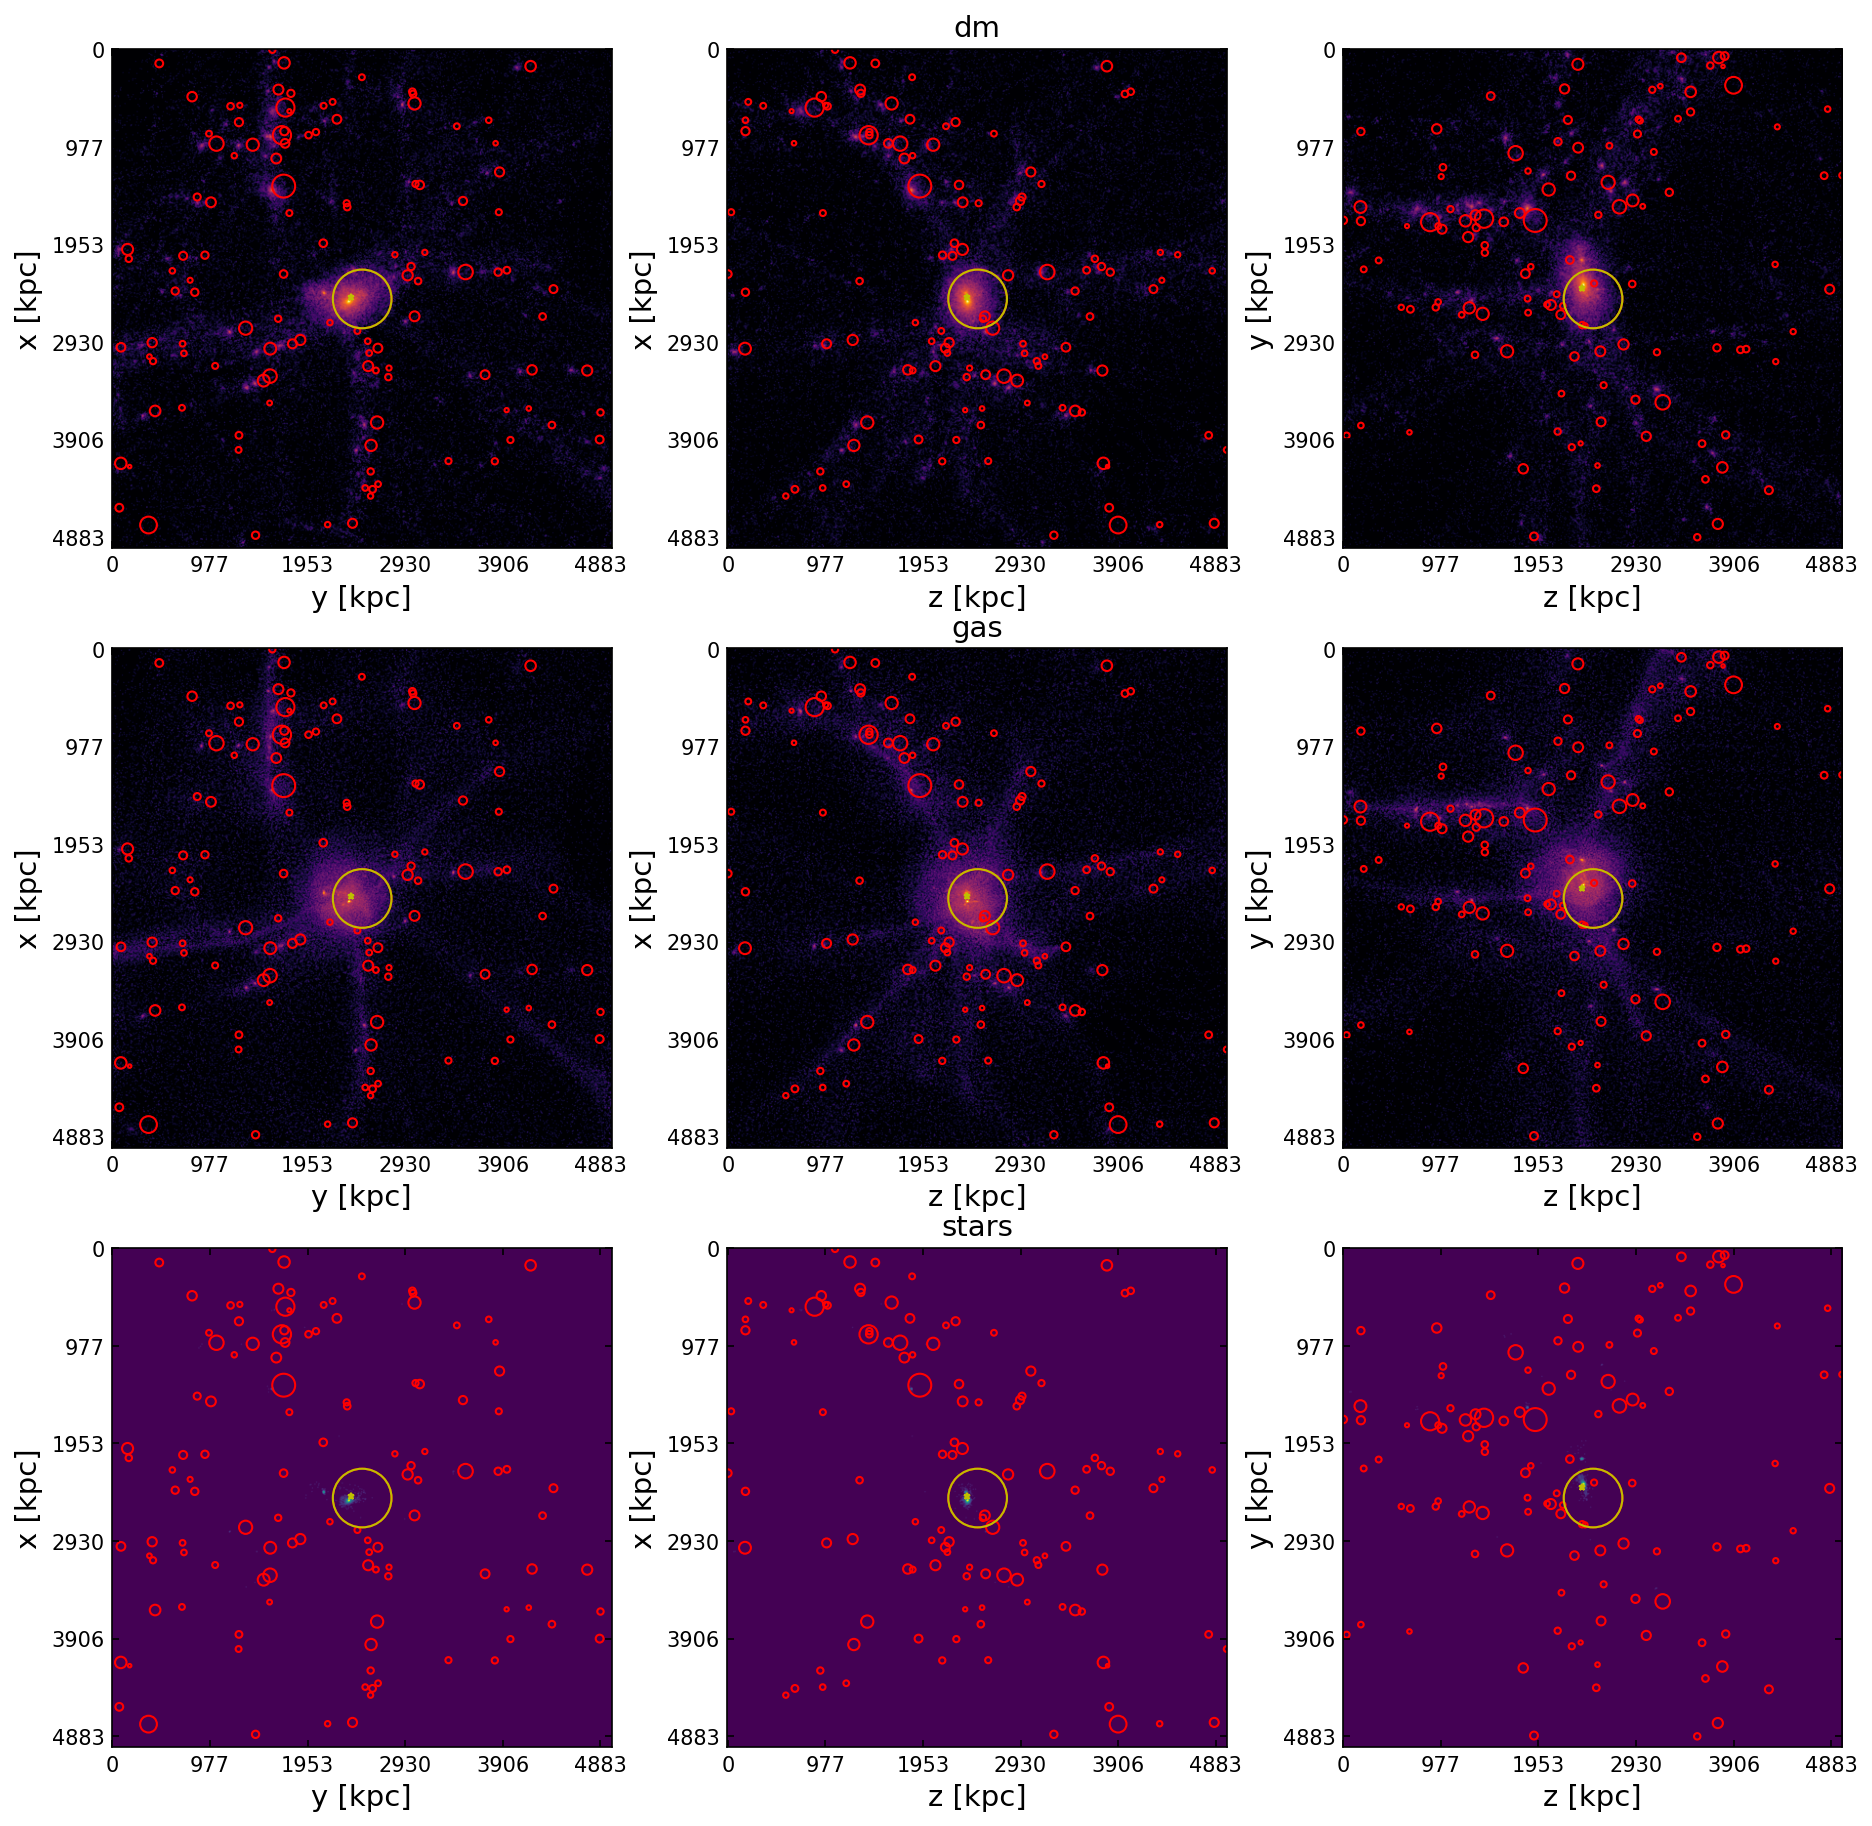

In [ ]:
Pmtng_norm = (Pmtng-xmin[np.newaxis, :])/L_p * 512
Pzoom_norm = (Pzoom-xmin[np.newaxis, :])/L_p * 512

fig, ax = plt.subplots(3, 3, dpi=150, figsize=(15,15))

cmap = ['inferno', 'inferno', 'viridis']

for type in range(len(part)):
    ax[type, 0].imshow(np.log10(1+np.sum(zoom_grid[part[type]][0,:,:,:],axis=2)), cmap=cmap[type])
    ax[type, 1].imshow(np.log10(1+np.sum(zoom_grid[part[type]][0,:,:,:],axis=1)), cmap=cmap[type])
    ax[type, 2].imshow(np.log10(1+np.sum(zoom_grid[part[type]][0,:,:,:],axis=0)), cmap=cmap[type])

    for i in range(3):
        xticklabels = 1000 * ax[type, i].get_xticks() / 512 * L_p
        yticklabels = 1000 * ax[type, i].get_yticks() / 512 * L_p
        ax[type, i].set_xticklabels(['{:.0f}'.format(xticklabels[i]) for i in range(len(xticklabels))])
        ax[type, i].set_yticklabels(['{:.0f}'.format(yticklabels[i]) for i in range(len(yticklabels))])

    ax[type, 0].set_xlabel('y [kpc]', fontsize=14)
    ax[type, 0].set_ylabel('x [kpc]', fontsize=14)

    ax[type, 1].set_xlabel('z [kpc]', fontsize=14)
    ax[type, 1].set_ylabel('x [kpc]', fontsize=14)

    ax[type, 2].set_xlabel('z [kpc]', fontsize=14)
    ax[type, 2].set_ylabel('y [kpc]', fontsize=14)

    ax[type, 1].set_title(part[type], fontsize=14)

    for i in range(sel_pos.shape[0]):
        circle = plt.Circle((sel_pos[i,1],sel_pos[i,0]), mtng.fof['halo_r200c'][mtng_sel][i]/L_p*512, color='r', fill=False)
        ax[type, 0].add_artist(circle)
        circle = plt.Circle((sel_pos[i,2],sel_pos[i,0]), mtng.fof['halo_r200c'][mtng_sel][i]/L_p*512, color='r', fill=False)
        ax[type, 1].add_artist(circle)
        circle = plt.Circle((sel_pos[i,2],sel_pos[i,1]), mtng.fof['halo_r200c'][mtng_sel][i]/L_p*512, color='r', fill=False)
        ax[type, 2].add_artist(circle)

    ax[type, 0].plot( Pzoom_norm[ihalo][1], Pzoom_norm[ihalo][0], 'y*', ms=3)
    ax[type, 1].plot( Pzoom_norm[ihalo][2], Pzoom_norm[ihalo][0], 'y*', ms=3)
    ax[type, 2].plot( Pzoom_norm[ihalo][2], Pzoom_norm[ihalo][1], 'y*', ms=3)

    circle = plt.Circle((Pmtng_norm[ihalo][1], Pmtng_norm[ihalo][0]), mtng.fof['halo_r200c'][sel_z][ihalo]/L_p*512, color='y', fill=False)
    ax[type, 0].add_artist(circle)
    circle = plt.Circle((Pmtng_norm[ihalo][2], Pmtng_norm[ihalo][0]), mtng.fof['halo_r200c'][sel_z][ihalo]/L_p*512, color='y', fill=False)
    ax[type, 1].add_artist(circle)
    circle = plt.Circle((Pmtng_norm[ihalo][2], Pmtng_norm[ihalo][1]), mtng.fof['halo_r200c'][sel_z][ihalo]/L_p*512, color='y', fill=False)
    ax[type, 2].add_artist(circle)

plt.savefig('../images/zoom_snap{:d}_{:d}_fid.pdf'.format(snap, ihalo), bbox_inches='tight')

### Save the cross-match

In [ ]:
np.save("/lscratch/fgmaion/MTNG-resims/cross-match/xmatch_fid.npy", [{'xmatch':psel[xmatch], 'dmatch':dmatch}])

In [ ]:
import h5py

In [ ]:
with h5py.File('/cosmos_storage/data_sharing/MN5_resims/fiducial/hydro_output/snapdir_094/snapshot_094.0.hdf5', 'r') as f:
    print(np.uint64(f['PartType1']['ParticleIDs']))

[66105314 66113042 66113277 ... 56374473 56374732 56374526]


In [ ]:
ic_file = '/cosmos_storage/data_sharing/MN5_resims/ICs_1pmbin_2160/output/snapdir_000/snapshot_ics_000'

ptype=1
part_type = 'PartType{0}'.format(ptype)

with h5py.File('/cosmos_storage/data_sharing/MN5_resims/ICs_1pmbin_2160/output/snapdir_000/snapshot_ics_000.1.hdf5', 'r') as f:
    nfiles = f['Header'].attrs['NumFilesPerSnapshot']
    numpart = f['Header'].attrs['NumPart_Total'][ptype]



In [ ]:
ids_ICs = np.zeros((numpart), dtype=np.int64)

istart = np.uint64(0)
for ifile in range(0, nfiles):

    ffname = ic_file+'.hdf5' if nfiles== 1 else ic_file+(
        '.%d.hdf5'%ifile)

    with h5py.File(ffname, 'r') as f: 
        npts = np.uint64(f['Header'].attrs['NumPart_ThisFile'][ptype])

        if npts > 0:
            ids_ICs[istart:istart + npts] = np.int64(f[part_type]['ParticleIDs'])

        istart += npts

In [ ]:
file = '/cosmos_storage/data_sharing/MN5_resims/fiducial/hydro_output/snapdir_264/snapshot_264'

ptype=1
part_type = 'PartType{0}'.format(ptype)

with h5py.File('/cosmos_storage/data_sharing/MN5_resims/fiducial/hydro_output/snapdir_264/snapshot_264.0.hdf5', 'r') as f:
    nfiles = f['Header'].attrs['NumFilesPerSnapshot']
    numpart = f['Header'].attrs['NumPart_Total'][ptype]


In [ ]:
ids = np.zeros((numpart), dtype=np.int64)

istart = np.uint64(0)
for ifile in range(0, nfiles):

    ffname = file+'.hdf5' if nfiles== 1 else file+(
        '.%d.hdf5'%ifile)

    with h5py.File(ffname, 'r') as f: 
        npts = np.uint64(f['Header'].attrs['NumPart_ThisFile'][ptype])

        if npts > 0:
            ids[istart:istart + npts] = np.int64(f[part_type]['ParticleIDs'])

        istart += npts

In [ ]:
sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME

base_ics = "/cosmos_storage/data_sharing/MN5_resims/ICs_1pmbin_2160/output/"
zoom_ics = bacco.Simulation(basedir=base_ics, halo_file="groups_000/fof_subhalo_tab_000", dm_file="snapdir_000/snapshot_ics_000", sim_format='TNG500', fixedPk=True, use_orphans=False,\
                        tau=tau, ns=ns, sigma8=sigma8, use_ids=True, numpart=4320**3)

2024-08-27 14:05:45,835 bacco.sims : Initialising simulation Default
2024-08-27 14:05:45,836 bacco.sims : try /cosmos_storage/data_sharing/MN5_resims/ICs_1pmbin_2160/output/snapdir_000/snapshot_ics_000


2024-08-27 14:05:45,839 bacco.sims : Loading /cosmos_storage/data_sharing/MN5_resims/ICs_1pmbin_2160/output/snapdir_000/snapshot_ics_000
2024-08-27 14:05:45,847 bacco.sims : Creating snapshot array from /cosmos_storage/data_sharing/MN5_resims/ICs_1pmbin_2160/output/snapdir_000/snapshot_ics_000 because: exists=True, newer=False
/scratch/fgmaion/baccogit/bacco/simulation.py:1401: UserWarning: loadtxt: input contained no data: "/cosmos_storage/data_sharing/MN5_resims/ICs_1pmbin_2160/output//snaplist.txt"
  tab = np.loadtxt(self.BaseDir + '/snaplist.txt')
2024-08-27 14:05:45,887 bacco.sims : Warning: Empty snaplist.txt
2024-08-27 14:05:45,888 bacco.sims : ...done in 0.0119 s


In [ ]:
zoom_ics.dm['ids']

array([     5622,      5623,      5624, ..., 118031090, 118031091,
       118031092])